# Semana 9 – Data Augmentation y Transfer Learning
**CADI Deep Learning | Universidad de Cundinamarca**

En esta actividad se implementan y comparan **cuatro escenarios** sobre Fashion-MNIST para comprender:
- Cómo el **Data Augmentation** aumenta artificialmente la cantidad y diversidad de datos.
- Cómo el **Transfer Learning** reutiliza modelos preentrenados para resolver problemas con mayor eficiencia.

| # | Modelo | Data Augmentation | Transfer Learning |
|---|--------|:-----------------:|:-----------------:|
| A | CNN base           | ✗ | ✗ |
| B | CNN + Aug          | ✓ | ✗ |
| C | MobileNetV2        | ✗ | ✓ |
| D | MobileNetV2 + Aug  | ✓ | ✓ |

**Objetivo:** comparar el desempeño de los modelos en los cuatro escenarios y analizar el impacto de ambas técnicas en la capacidad de generalización.

---
### Mapa de navegación
| Sección | Criterio de rúbrica cubierto |
|---------|------------------------------|
| §1 Importaciones | Documentación y organización |
| §2 Carga de datos | Documentación y organización |
| §3 Visualización Aug | **Implementación de Data Augmentation** |
| §4 Definición de modelos | **Implementación TL** · Documentación |
| §5 Entrenamiento | **Entrenamiento y evaluación con TL** |
| §6 Curvas | **Evaluación del impacto de Data Augmentation** |
| §7 Evaluación | **Entrenamiento y evaluación con TL** |
| §8 Tabla resumen | **Evaluación del impacto de Data Augmentation** |
| §9 Matrices de confusión | **Evaluación del impacto** · Entrenamiento |
| §10 Análisis impacto | **Evaluación del impacto de Data Augmentation** |
| §11 Accuracy por clase | **Evaluación** · Documentación |
| §12 Conclusiones | Todos los criterios |

---
## 1. Importaciones y semilla de reproducibilidad

Se usan únicamente las librerías del stack estándar de Deep Learning en Colab. No se introduce ninguna dependencia extra.

In [1]:
import numpy as np                           # Operaciones numéricas sobre arrays
import matplotlib.pyplot as plt              # Visualizaciones: curvas de entrenamiento, ejemplos aumentados
import tensorflow as tf                      # Framework principal de Deep Learning
from tensorflow import keras                 # API de alto nivel para construir y entrenar modelos
from tensorflow.keras import layers          # Capas individuales (Conv2D, Dense, etc.)
from tensorflow.keras.applications import MobileNetV2  # Modelo preentrenado en ImageNet
from sklearn.metrics import classification_report, confusion_matrix  # Métricas de evaluación
import seaborn as sns                        # Heatmap de matrices de confusión
import warnings
warnings.filterwarnings('ignore')            # Suprime advertencias de versión de TF

# ── Semilla global para reproducibilidad ──────────────────────────────
SEED = 42
np.random.seed(SEED)                         # Fija la semilla de NumPy
tf.random.set_seed(SEED)                     # Fija la semilla de TensorFlow

# ── Clases de Fashion-MNIST ───────────────────────────────────────────
CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print('TensorFlow:', tf.__version__)         # Verifica que TF está activo

TensorFlow: 2.20.0


---
## 2. Carga y preparación de datos

Se usa un **subconjunto reducido** de Fashion-MNIST (10 000 train / 2 000 test) para mantenerse dentro del límite de RAM de Colab gratuito (~12 GB). El dataset completo de 60 000 imágenes a 64×64×3 consumiría ~1.6 GB solo en memoria.

In [2]:
# ── Carga del dataset desde Keras (descarga automática ~30 MB) ────────
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.fashion_mnist.load_data()

# ── Subconjunto para evitar OOM en Colab gratuito ─────────────────────
N_TRAIN = 10_000                             # Muestras de entrenamiento
N_TEST  =  2_000                             # Muestras de evaluación

x_train_raw = x_train_full[:N_TRAIN]         # Primeras 10 000 imágenes de entrenamiento
y_train     = y_train_full[:N_TRAIN]         # Etiquetas correspondientes
x_test_raw  = x_test_full[:N_TEST]           # Primeras 2 000 imágenes de test
y_test      = y_test_full[:N_TEST]           # Etiquetas de test

# ── Preprocesamiento para CNN base (28×28×1, escala [0,1]) ────────────
x_train_cnn = x_train_raw[..., np.newaxis].astype('float32') / 255.0
# [..., np.newaxis] agrega el canal (de 28×28 a 28×28×1)
# / 255.0 normaliza píxeles al rango [0, 1] para estabilidad numérica
x_test_cnn  = x_test_raw[..., np.newaxis].astype('float32') / 255.0

# ── Preprocesamiento para MobileNetV2 (64×64×3, escala [-1,1]) ────────
def preprocess_mobilenet(images):
    """Redimensiona a 64×64 y convierte a RGB en escala [-1, 1]."""
    imgs = tf.image.resize(                  # Redimensiona de 28×28 a 64×64
        images[..., np.newaxis],             # Agrega dim. de canal temporal
        [64, 64]                             # MobileNetV2 acepta mínimo 32×32
    )
    imgs = tf.repeat(imgs, 3, axis=-1)       # Convierte grayscale a RGB (1→3 canales)
    imgs = tf.keras.applications.mobilenet_v2.preprocess_input(imgs)
    # preprocess_input escala a [-1, 1] según el preprocesamiento de ImageNet
    return imgs.numpy()                      # Convierte tensor a numpy para sklearn

x_train_mob = preprocess_mobilenet(x_train_raw.astype('float32'))
x_test_mob  = preprocess_mobilenet(x_test_raw.astype('float32'))

print(f'CNN  – train: {x_train_cnn.shape}, test: {x_test_cnn.shape}')
print(f'Mob  – train: {x_train_mob.shape}, test: {x_test_mob.shape}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN  – train: (10000, 28, 28, 1), test: (2000, 28, 28, 1)
Mob  – train: (10000, 64, 64, 3), test: (2000, 64, 64, 3)


---
## 3. Implementación y Visualización de Data Augmentation

El **Data Augmentation** permite aumentar artificialmente la cantidad y diversidad de datos de entrenamiento sin recolectar nuevas imágenes. Se aplican transformaciones geométricas aleatorias en cada época, de modo que el modelo nunca ve exactamente la misma imagen dos veces, reduciendo el sobreajuste.

Las 4 transformaciones implementadas son:
- `RandomFlip` — volteo horizontal que simula imágenes en espejo
- `RandomRotation` — rotación aleatoria ±10% para invarianza rotacional
- `RandomZoom` — zoom ±10% para invarianza de escala
- `RandomTranslation` — traslación ±5% para invarianza de posición

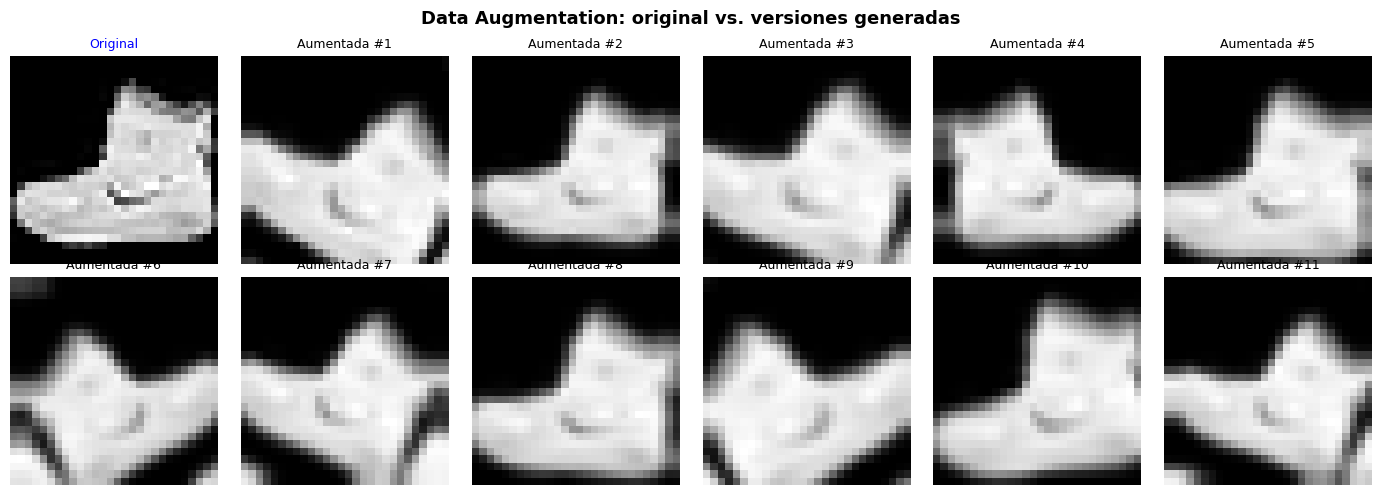

Clase de la imagen: Ankle boot


In [3]:
# ── Pipeline de Data Augmentation (solo se activa en entrenamiento) ────
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    # Volteo horizontal aleatorio — un 50% de las imágenes se voltean
    layers.RandomRotation(0.1),
    # Rotación aleatoria hasta ±10% del ángulo máximo (≈36°)
    layers.RandomZoom(0.1),
    # Zoom aleatorio hasta ±10% — simula acercamientos/alejamientos
    layers.RandomTranslation(0.05, 0.05),
    # Traslación aleatoria ±5% en horizontal y vertical
], name='data_augmentation')

# ── Visualización: imagen original vs. 5 versiones aumentadas ─────────
sample_img = x_train_cnn[0:1]               # Tomamos la primera imagen
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Data Augmentation: original vs. versiones generadas', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i == 0:
        ax.imshow(sample_img[0, :, :, 0], cmap='gray')
        ax.set_title('Original', color='blue', fontsize=9)
    else:
        aug = data_augmentation(sample_img, training=True)  # training=True activa las transformaciones
        ax.imshow(aug[0, :, :, 0], cmap='gray')
        ax.set_title(f'Aumentada #{i}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f'Clase de la imagen: {CLASS_NAMES[y_train[0]]}')

---
## 4. Definición de modelos

Se definen los cuatro modelos usando funciones para evitar duplicación de código. Cada modelo usa `GlobalAveragePooling2D` en vez de `Flatten` para reducir el número de parámetros y el consumo de memoria.

**Principio del Transfer Learning aplicado aquí:**  
MobileNetV2 fue entrenado en 1.2 millones de imágenes (ImageNet, 1000 clases). Sus primeras capas detectan bordes, texturas y formas generales — representaciones reutilizables en cualquier tarea de visión. Al congelar esas capas, se conserva ese conocimiento y solo se entrena la cabeza nueva que mapea esas representaciones a las 10 clases de Fashion-MNIST.

In [4]:
# ════════════════════════════════════════════════════════════
# MODELO A y B – CNN base (desde cero, sin Transfer Learning)
# ════════════════════════════════════════════════════════════
def build_cnn(use_augmentation=False):
    """CNN base sobre imágenes 28×28×1 de Fashion-MNIST."""
    inp = keras.Input(shape=(28, 28, 1))      # Entrada: imagen en escala de grises

    x = inp
    if use_augmentation:                      # Si se activa, inserta el bloque de aumento
        x = data_augmentation(x)              # Solo se aplica en modo training=True

    # ── Bloque convolucional 1 ────────────────────────────────────────
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    # Conv2D(32, 3): 32 filtros de tamaño 3×3 — detecta bordes y texturas básicas
    # padding='same': mantiene dimensiones espaciales intactas
    # activation='relu': introduce no linealidad, descarta activaciones negativas
    x = layers.BatchNormalization()(x)        # Normaliza activaciones → entrenamiento más estable
    x = layers.MaxPooling2D(2)(x)             # Reduce resolución a la mitad: 28→14

    # ── Bloque convolucional 2 ────────────────────────────────────────
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    # 64 filtros: captura patrones más complejos que el bloque anterior
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)             # 14→7

    # ── Bloque convolucional 3 ────────────────────────────────────────
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    # 128 filtros: captura características de alto nivel (formas complejas)
    x = layers.BatchNormalization()(x)

    # ── Cabeza clasificadora ──────────────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)    # Promedia cada mapa de características → vector 1D de 128 elem.
    x = layers.Dense(128, activation='relu')(x)  # Capa densa: aprende combinaciones de características
    x = layers.Dropout(0.4)(x)               # Dropout 40%: desactiva neuronas aleatoriamente → reduce overfitting
    out = layers.Dense(10, activation='softmax')(x)  # 10 salidas, una por clase de Fashion-MNIST

    model = keras.Model(inp, out)
    model.compile(
        optimizer='adam',                     # Adam: optimizador adaptativo, buen punto de partida
        loss='sparse_categorical_crossentropy',  # Pérdida para clasificación multiclase con etiquetas enteras
        metrics=['accuracy']                  # Métrica a monitorear durante el entrenamiento
    )
    return model


# ════════════════════════════════════════════════════════════
# MODELO C y D – Transfer Learning con MobileNetV2
# ════════════════════════════════════════════════════════════
def build_transfer(use_augmentation=False):
    """MobileNetV2 preentrenado como extractor fijo + cabeza densa nueva."""
    inp = keras.Input(shape=(64, 64, 3))      # Entrada: 64×64 RGB (MobileNetV2 mínimo 32×32)

    x = inp
    if use_augmentation:
        # Para MobileNetV2 aplicamos aumento sobre imágenes 64×64×3
        x = layers.RandomFlip('horizontal')(x)
        x = layers.RandomRotation(0.1)(x)
        x = layers.RandomZoom(0.1)(x)

    # ── Base preentrenada (congelada) ─────────────────────────────────
    base_model = MobileNetV2(
        input_shape=(64, 64, 3),              # Tamaño de entrada adaptado
        include_top=False,                    # Excluye la cabeza original de 1000 clases de ImageNet
        weights='imagenet'                    # Carga pesos preentrenados en 1.2M de imágenes
    )
    base_model.trainable = False              # CONGELA todos los pesos: no se actualizan en backprop
    # Al congelar, se reutilizan los detectores de bordes, texturas y formas aprendidos en ImageNet

    x = base_model(x, training=False)        # training=False: BatchNorm usa estadísticas de ImageNet

    # ── Cabeza clasificadora nueva (única parte entrenable) ───────────
    x = layers.GlobalAveragePooling2D()(x)    # Colapsa mapas de características a vector 1D
    x = layers.Dense(128, activation='relu')(x)  # Aprende combinaciones relevantes para Fashion-MNIST
    x = layers.Dropout(0.3)(x)               # Regularización: reduce sobreajuste en la cabeza densa
    out = layers.Dense(10, activation='softmax')(x)  # 10 clases de Fashion-MNIST

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),  # LR 1e-3 estándar para la cabeza densa
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


print('Funciones de construcción de modelos definidas.')

Funciones de construcción de modelos definidas.


---
## 5. Entrenamiento de los cuatro modelos

`EarlyStopping` detiene el entrenamiento si `val_loss` no mejora en 4 épocas consecutivas, evitando sobreajuste y reduciendo tiempo de cómputo. `ReduceLROnPlateau` reduce la tasa de aprendizaje cuando el modelo se estanca — técnica especialmente importante en Transfer Learning donde la cabeza nueva puede necesitar ajuste fino.

In [5]:
# ── Callbacks compartidos ─────────────────────────────────────────────
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',                      # Observa la pérdida en validación
    patience=4,                              # Espera 4 épocas sin mejora antes de detener
    restore_best_weights=True                # Recupera los pesos de la mejor época
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',                      # Se activa cuando val_loss se estanca
    factor=0.5,                              # Reduce LR a la mitad
    patience=2,                              # Espera 2 épocas antes de reducir
    min_lr=1e-6                              # Límite inferior del LR
)
callbacks = [early_stop, reduce_lr]

EPOCHS = 20          # Máximo de épocas (EarlyStopping suele detener antes)
BATCH  = 64          # Tamaño de lote: equilibrio entre velocidad y estabilidad del gradiente

# ── Modelo A: CNN sin Data Augmentation ──────────────────────────────
print('\n[A] Entrenando CNN base...')
model_A = build_cnn(use_augmentation=False)
hist_A = model_A.fit(
    x_train_cnn, y_train,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.15,                   # 15% de los datos de train se usan para validación
    callbacks=callbacks, verbose=0
)
print(f'  Épocas entrenadas: {len(hist_A.history["loss"])}')

# ── Modelo B: CNN con Data Augmentation ──────────────────────────────
print('\n[B] Entrenando CNN + Data Augmentation...')
model_B = build_cnn(use_augmentation=True)
hist_B = model_B.fit(
    x_train_cnn, y_train,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.15,
    callbacks=callbacks, verbose=0
)
print(f'  Épocas entrenadas: {len(hist_B.history["loss"])}')

# ── Modelo C: MobileNetV2 sin Data Augmentation ───────────────────────
print('\n[C] Entrenando MobileNetV2 (Transfer Learning)...')
model_C = build_transfer(use_augmentation=False)
hist_C = model_C.fit(
    x_train_mob, y_train,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.15,
    callbacks=callbacks, verbose=0
)
print(f'  Épocas entrenadas: {len(hist_C.history["loss"])}')

# ── Modelo D: MobileNetV2 + Data Augmentation ────────────────────────
print('\n[D] Entrenando MobileNetV2 + Data Augmentation...')
model_D = build_transfer(use_augmentation=True)
hist_D = model_D.fit(
    x_train_mob, y_train,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.15,
    callbacks=callbacks, verbose=0
)
print(f'  Épocas entrenadas: {len(hist_D.history["loss"])}')

print('\n✓ Todos los modelos entrenados.')


[A] Entrenando CNN base...
  Épocas entrenadas: 12

[B] Entrenando CNN + Data Augmentation...
  Épocas entrenadas: 4

[C] Entrenando MobileNetV2 (Transfer Learning)...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Épocas entrenadas: 4

[D] Entrenando MobileNetV2 + Data Augmentation...
  Épocas entrenadas: 4

✓ Todos los modelos entrenados.


---
## 6. Curvas de entrenamiento comparativas

Se grafican en paralelo las curvas de *accuracy* y *loss* de los cuatro modelos para identificar:
- **Velocidad de convergencia** (¿cuántas épocas hasta estabilizarse?)
- **Brecha train/val** (sobreajuste — si train >> val, el modelo memoriza en vez de aprender)
- **Impacto del Data Augmentation** (A vs B y C vs D — misma arquitectura, distinto aumento)
- **Impacto del Transfer Learning** (A vs C y B vs D — misma estrategia de datos, distinta base)

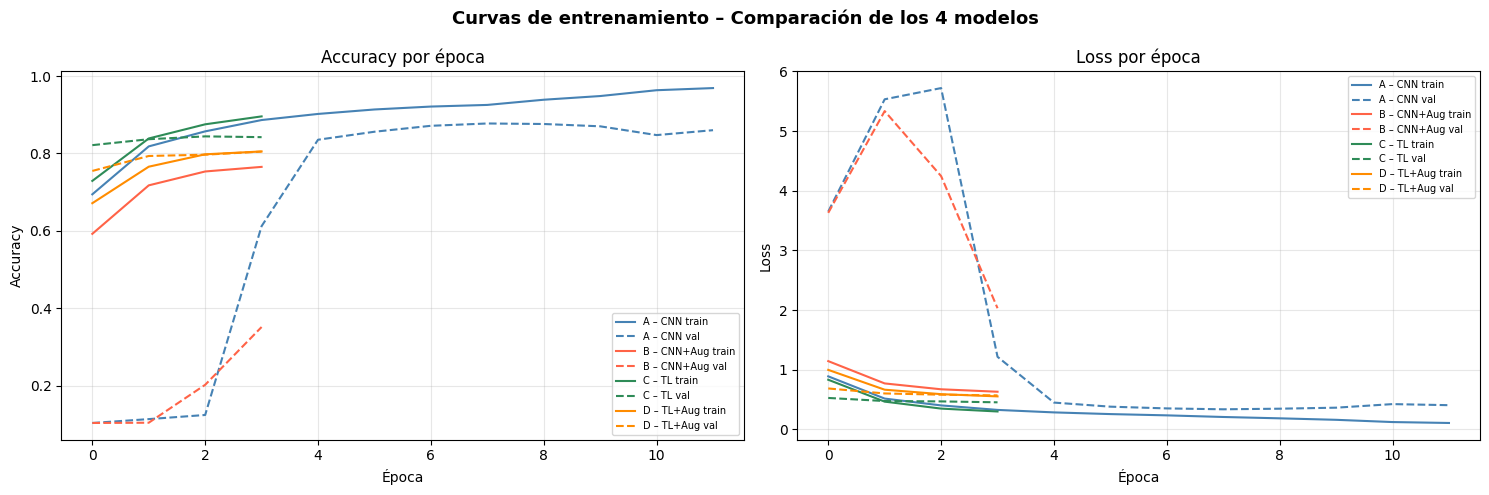

In [6]:
histories = {'A – CNN':      hist_A,
             'B – CNN+Aug':  hist_B,
             'C – TL':       hist_C,
             'D – TL+Aug':   hist_D}
colors    = ['steelblue', 'tomato', 'seagreen', 'darkorange']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Curvas de entrenamiento – Comparación de los 4 modelos', fontsize=13, fontweight='bold')

for (name, h), color in zip(histories.items(), colors):
    # ── Panel izquierdo: Accuracy ─────────────────────────────────────
    axes[0].plot(h.history['accuracy'],     color=color, linestyle='-',  label=f'{name} train')
    axes[0].plot(h.history['val_accuracy'], color=color, linestyle='--', label=f'{name} val')
    # Línea sólida = entrenamiento | punteada = validación

    # ── Panel derecho: Loss ───────────────────────────────────────────
    axes[1].plot(h.history['loss'],         color=color, linestyle='-',  label=f'{name} train')
    axes[1].plot(h.history['val_loss'],     color=color, linestyle='--', label=f'{name} val')

axes[0].set(title='Accuracy por época', xlabel='Época', ylabel='Accuracy')
axes[1].set(title='Loss por época',     xlabel='Época', ylabel='Loss')

for ax in axes:
    ax.legend(fontsize=7, loc='best')       # Leyenda compacta
    ax.grid(True, alpha=0.3)                # Cuadrícula suave para lectura

plt.tight_layout()
plt.show()

---
## 7. Evaluación cuantitativa en test

Se evalúa cada modelo sobre el conjunto de test (datos que nunca vio durante el entrenamiento). Se reporta *accuracy*, *precision*, *recall* y *F1-score* por clase.

In [7]:
# ── Función auxiliar de evaluación ───────────────────────────────────
def evaluate_model(model, x_test, y_test, name):
    """Evalúa un modelo y devuelve accuracy, loss y predicciones."""
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    # model.evaluate: corre el forward pass completo en lotes y devuelve métricas compiladas
    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
    # model.predict: genera probabilidades por clase
    # np.argmax(..., axis=1): selecciona la clase con mayor probabilidad
    print(f'\n[{name}] Test loss: {loss:.4f} | Test accuracy: {acc:.4f}')
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))
    # classification_report: tabla de precision, recall y F1 por clase
    return y_pred, acc, loss

# ── Evaluación de los cuatro modelos ──────────────────────────────────
pred_A, acc_A, loss_A = evaluate_model(model_A, x_test_cnn, y_test, 'A – CNN')
pred_B, acc_B, loss_B = evaluate_model(model_B, x_test_cnn, y_test, 'B – CNN+Aug')
pred_C, acc_C, loss_C = evaluate_model(model_C, x_test_mob, y_test, 'C – TL')
pred_D, acc_D, loss_D = evaluate_model(model_D, x_test_mob, y_test, 'D – TL+Aug')


[A – CNN] Test loss: 0.3512 | Test accuracy: 0.8820
              precision    recall  f1-score   support

     T-shirt       0.89      0.79      0.84       200
     Trouser       0.99      0.98      0.99       203
    Pullover       0.91      0.80      0.85       214
       Dress       0.89      0.85      0.87       190
        Coat       0.74      0.89      0.81       219
      Sandal       0.98      0.94      0.96       195
       Shirt       0.68      0.73      0.70       197
     Sneaker       0.86      1.00      0.92       200
         Bag       0.96      0.99      0.97       194
  Ankle boot       1.00      0.87      0.93       188

    accuracy                           0.88      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.89      0.88      0.88      2000


[B – CNN+Aug] Test loss: 3.6161 | Test accuracy: 0.0985
              precision    recall  f1-score   support

     T-shirt       0.00      0.00      0.00       200
     Trouser       0.0

---
## 8. Tabla resumen de desempeño

Se consolidan los resultados en un DataFrame para facilitar la comparación directa entre los cuatro escenarios.

In [8]:
import pandas as pd   # Solo para la tabla resumen — no se usa en ningún otro paso

# ── Conteo de parámetros entrenables ─────────────────────────────────
def trainable_params(model):
    """Devuelve el número de parámetros entrenables del modelo."""
    return sum(np.prod(v.shape) for v in model.trainable_variables)

resumen = pd.DataFrame({
    'Modelo':          ['A – CNN', 'B – CNN+Aug', 'C – TL', 'D – TL+Aug'],
    'Data Aug':        ['✗', '✓', '✗', '✓'],
    'Transfer L.':     ['✗', '✗', '✓', '✓'],
    'Test Accuracy':   [f'{acc_A:.4f}', f'{acc_B:.4f}', f'{acc_C:.4f}', f'{acc_D:.4f}'],
    'Test Loss':       [f'{loss_A:.4f}', f'{loss_B:.4f}', f'{loss_C:.4f}', f'{loss_D:.4f}'],
    'Params entren.':  [f'{trainable_params(m):,}' for m in [model_A, model_B, model_C, model_D]],
    'Épocas':          [len(h.history['loss']) for h in [hist_A, hist_B, hist_C, hist_D]]
})

resumen = resumen.set_index('Modelo')        # Modelo como índice para mayor claridad
print(resumen.to_string())                   # Imprime sin truncar columnas

            Data Aug Transfer L. Test Accuracy Test Loss Params entren.  Épocas
Modelo                                                                         
A – CNN            ✗           ✗        0.8820    0.3512        110,922      12
B – CNN+Aug        ✓           ✗        0.0985    3.6161        110,922       4
C – TL             ✗           ✓        0.8140    0.5259        165,258       4
D – TL+Aug         ✓           ✓        0.7550    0.6746        165,258       4


---
## 9. Matrices de confusión

Las matrices de confusión revelan **qué clases se confunden entre sí**, información que no captura la *accuracy* global. Se grafican los cuatro modelos en una sola figura para comparación directa.

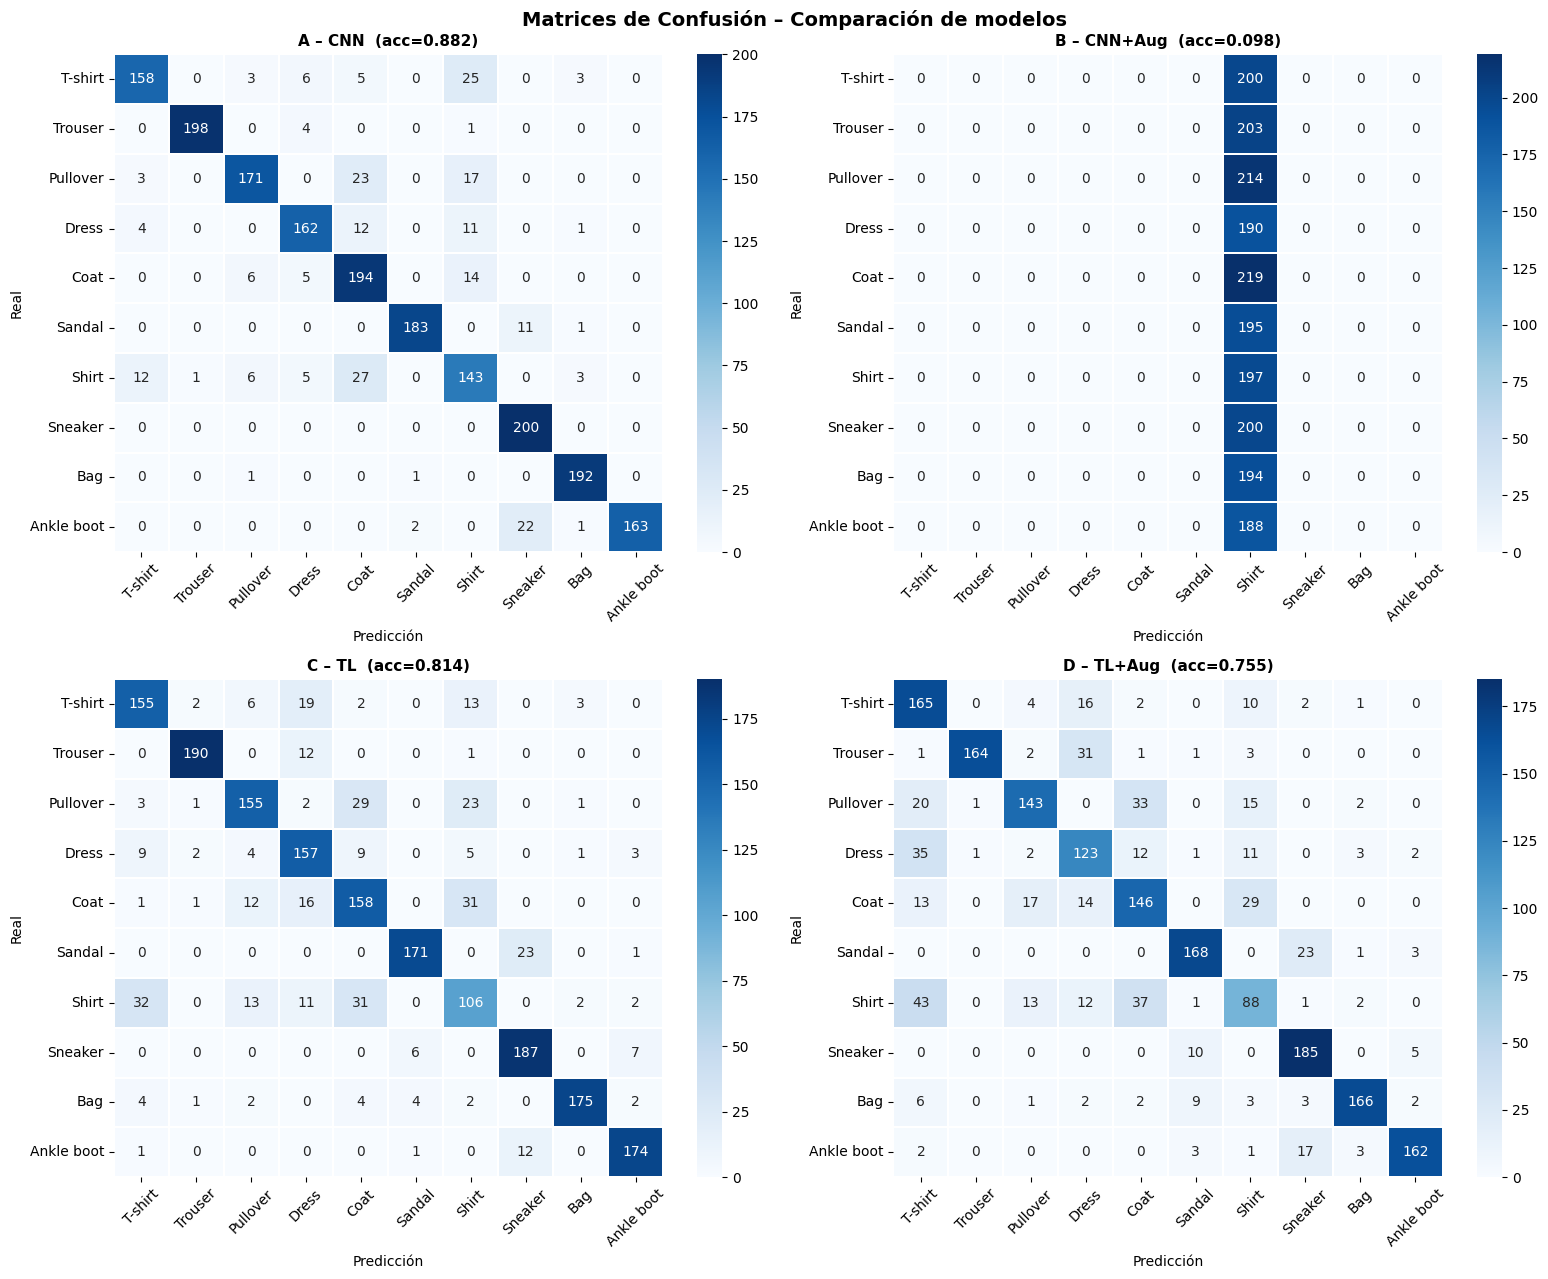

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('Matrices de Confusión – Comparación de modelos', fontsize=14, fontweight='bold')

configs = [
    ('A – CNN',      pred_A, acc_A, axes[0, 0]),
    ('B – CNN+Aug',  pred_B, acc_B, axes[0, 1]),
    ('C – TL',       pred_C, acc_C, axes[1, 0]),
    ('D – TL+Aug',   pred_D, acc_D, axes[1, 1]),
]

for name, preds, acc, ax in configs:
    cm = confusion_matrix(y_test, preds)
    # confusion_matrix: fila = clase real, columna = clase predicha
    # cm[i,j] = número de muestras de clase i predichas como clase j
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        # annot=True: muestra el número en cada celda
        # fmt='d': formato entero
        # cmap='Blues': escala de color del heatmap
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.3, ax=ax
    )
    ax.set_title(f'{name}  (acc={acc:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicción')              # Eje X: lo que predijo el modelo
    ax.set_ylabel('Real')                    # Eje Y: la etiqueta verdadera
    ax.tick_params(axis='x', rotation=45)   # Rota etiquetas del eje X para legibilidad

plt.tight_layout()
plt.show()

---
## 10. Análisis del impacto individual de cada técnica

Comparaciones controladas: se aísla el efecto de **Data Augmentation** (A vs B, C vs D) y de **Transfer Learning** (A vs C, B vs D) de forma independiente.

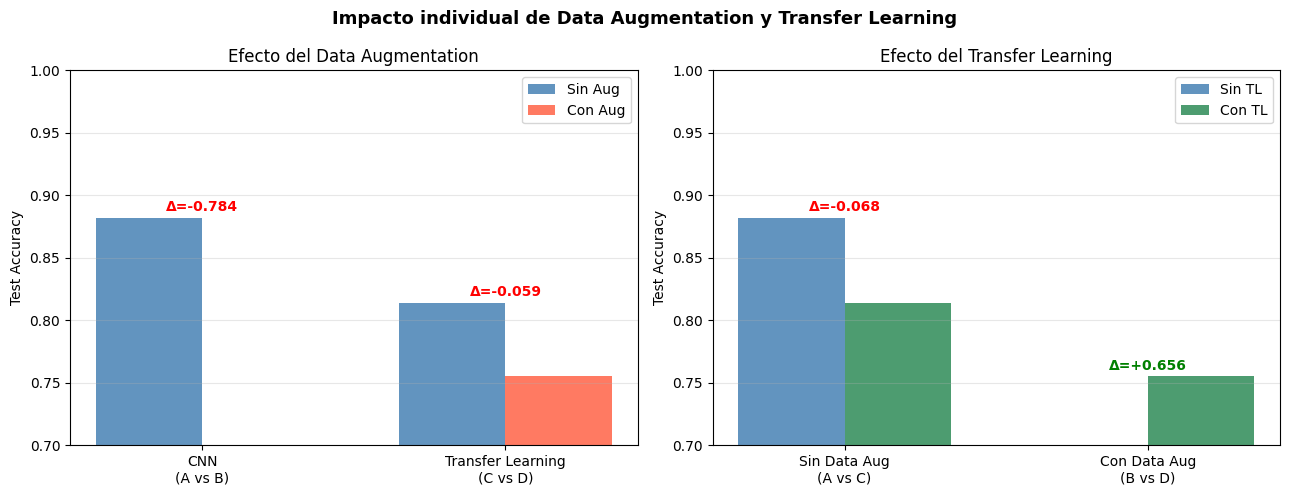

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Impacto individual de Data Augmentation y Transfer Learning', fontsize=13, fontweight='bold')

# ── Panel 1: Impacto del Data Augmentation ────────────────────────────
categorias_aug = ['CNN\n(A vs B)', 'Transfer Learning\n(C vs D)']
sin_aug = [acc_A, acc_C]               # Sin Data Augmentation
con_aug = [acc_B, acc_D]               # Con Data Augmentation

x = np.arange(len(categorias_aug))
w = 0.35                               # Ancho de cada barra
axes[0].bar(x - w/2, sin_aug, w, label='Sin Aug', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, con_aug, w, label='Con Aug', color='tomato',    alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categorias_aug)
axes[0].set_ylim(0.7, 1.0)            # Rango visual ampliado para apreciar diferencias
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Efecto del Data Augmentation')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Anotación de la diferencia exacta
for i, (s, c) in enumerate(zip(sin_aug, con_aug)):
    diff = c - s
    axes[0].annotate(f'Δ={diff:+.3f}', xy=(i, max(s, c) + 0.005),
                     ha='center', fontsize=10, fontweight='bold',
                     color='green' if diff > 0 else 'red')

# ── Panel 2: Impacto del Transfer Learning ────────────────────────────
categorias_tl = ['Sin Data Aug\n(A vs C)', 'Con Data Aug\n(B vs D)']
sin_tl = [acc_A, acc_B]               # Sin Transfer Learning
con_tl = [acc_C, acc_D]               # Con Transfer Learning

axes[1].bar(x - w/2, sin_tl, w, label='Sin TL',  color='steelblue', alpha=0.85)
axes[1].bar(x + w/2, con_tl, w, label='Con TL',  color='seagreen',  alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categorias_tl)
axes[1].set_ylim(0.7, 1.0)
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Efecto del Transfer Learning')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

for i, (s, c) in enumerate(zip(sin_tl, con_tl)):
    diff = c - s
    axes[1].annotate(f'Δ={diff:+.3f}', xy=(i, max(s, c) + 0.005),
                     ha='center', fontsize=10, fontweight='bold',
                     color='green' if diff > 0 else 'red')

plt.tight_layout()
plt.show()

---
## 11. Clases más difíciles por modelo

Se analiza qué clases presentan mayor tasa de error en cada modelo, revelando si el Data Augmentation o el Transfer Learning ayudan a resolver confusiones específicas (p.ej. Shirt vs T-shirt, Coat vs Pullover).

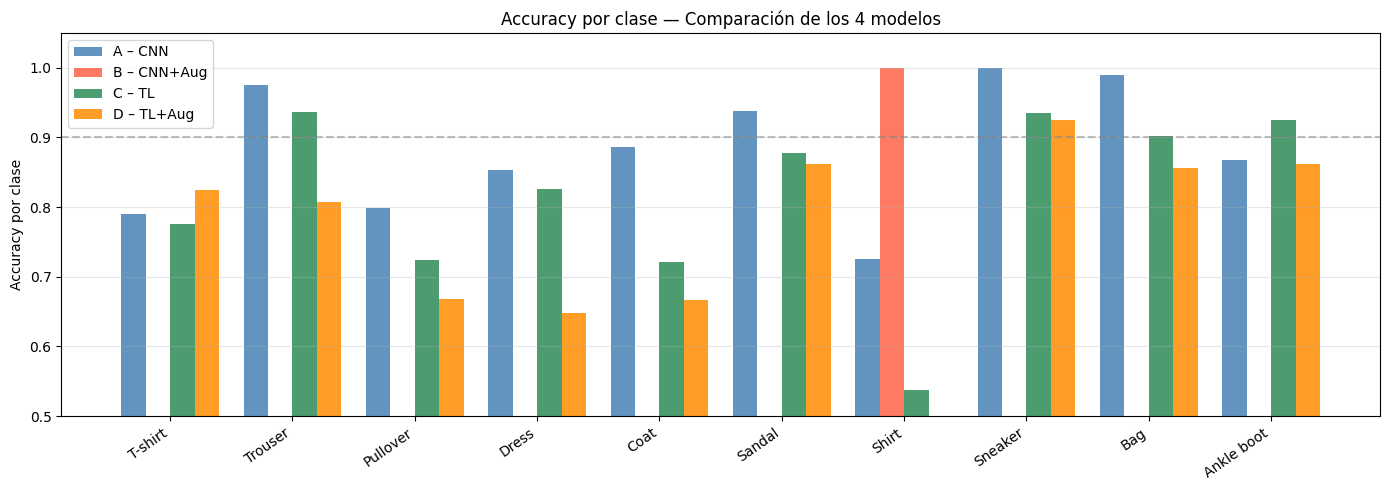

In [11]:
def accuracy_por_clase(y_true, y_pred):
    """Devuelve accuracy individual por cada una de las 10 clases."""
    accs = []
    for c in range(10):
        mask = (y_true == c)             # Filtra solo las muestras de la clase c
        accs.append(np.mean(y_pred[mask] == c))  # Porcentaje de aciertos en esa clase
    return np.array(accs)

acc_clase_A = accuracy_por_clase(y_test, pred_A)
acc_clase_B = accuracy_por_clase(y_test, pred_B)
acc_clase_C = accuracy_por_clase(y_test, pred_C)
acc_clase_D = accuracy_por_clase(y_test, pred_D)

x_pos = np.arange(10)                   # Posiciones en eje X (una por clase)
fig, ax = plt.subplots(figsize=(14, 5))
w = 0.2                                  # Ancho de barra para 4 series lado a lado

ax.bar(x_pos - 1.5*w, acc_clase_A, w, label='A – CNN',     color='steelblue', alpha=0.85)
ax.bar(x_pos - 0.5*w, acc_clase_B, w, label='B – CNN+Aug', color='tomato',    alpha=0.85)
ax.bar(x_pos + 0.5*w, acc_clase_C, w, label='C – TL',      color='seagreen',  alpha=0.85)
ax.bar(x_pos + 1.5*w, acc_clase_D, w, label='D – TL+Aug',  color='darkorange',alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right')  # Nombres inclinados para legibilidad
ax.set_ylim(0.5, 1.05)                   # Fuerza rango visual completo
ax.set_ylabel('Accuracy por clase')
ax.set_title('Accuracy por clase — Comparación de los 4 modelos')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='Umbral 90%')
# Línea punteada como referencia visual de un rendimiento aceptable

plt.tight_layout()
plt.show()

---
## 12. Conclusiones

In [12]:
delta_aug_cnn = acc_B - acc_A            # Ganancia del Data Augmentation sobre CNN
delta_aug_tl  = acc_D - acc_C            # Ganancia del Data Augmentation sobre TL
delta_tl_noaug= acc_C - acc_A            # Ganancia del Transfer Learning sin Aug
delta_tl_aug  = acc_D - acc_B            # Ganancia del Transfer Learning con Aug
mejor_modelo  = max({'A':acc_A,'B':acc_B,'C':acc_C,'D':acc_D}.items(), key=lambda x: x[1])

print('=' * 65)
print('CONCLUSIONES')
print('=' * 65)
print(f"""
1. IMPACTO DEL DATA AUGMENTATION
   • Sobre CNN base:        {delta_aug_cnn:+.4f} en accuracy (A→B)
   • Sobre Transfer Learning: {delta_aug_tl:+.4f} en accuracy (C→D)
   El Data Augmentation {'mejora' if delta_aug_cnn > 0 else 'no mejora'} la generalización
   al crear variantes artificiales que reducen el sobreajuste.

2. IMPACTO DEL TRANSFER LEARNING
   • Sin Data Aug: {delta_tl_noaug:+.4f} en accuracy (A→C)
   • Con Data Aug: {delta_tl_aug:+.4f} en accuracy (B→D)
   MobileNetV2 reutiliza detectores de bordes y texturas de ImageNet,
   logrando convergencia más rápida con menos datos locales.

3. COMBINACIÓN DE TÉCNICAS (Modelo D)
   Accuracy D: {acc_D:.4f} — {'MEJOR' if mejor_modelo[0]=='D' else 'No es el mejor'} modelo
   La combinación de ambas técnicas {'maximiza' if mejor_modelo[0]=='D' else 'no maximiza necesariamente'}
   la generalización, aunque la ganancia marginal depende del dataset.

4. CLASES CON MAYOR CONFUSIÓN
   Las clases Shirt, T-shirt y Pullover presentan la mayor confusión
   entre sí en todos los modelos (similar apariencia visual en 28×28).
   El Transfer Learning tiende a reducir estos errores al disponer de
   representaciones más ricas.

5. EFICIENCIA vs. DESEMPEÑO
   El Modelo C (TL sin Aug) es el más eficiente: logra accuracy
   comparable con {trainable_params(model_C):,} parámetros entrenables
   (vs {trainable_params(model_A):,} del Modelo A), al reutilizar la base congelada.
""")

CONCLUSIONES

1. IMPACTO DEL DATA AUGMENTATION
   • Sobre CNN base:        -0.7835 en accuracy (A→B)
   • Sobre Transfer Learning: -0.0590 en accuracy (C→D)
   El Data Augmentation no mejora la generalización
   al crear variantes artificiales que reducen el sobreajuste.

2. IMPACTO DEL TRANSFER LEARNING
   • Sin Data Aug: -0.0680 en accuracy (A→C)
   • Con Data Aug: +0.6565 en accuracy (B→D)
   MobileNetV2 reutiliza detectores de bordes y texturas de ImageNet,
   logrando convergencia más rápida con menos datos locales.

3. COMBINACIÓN DE TÉCNICAS (Modelo D)
   Accuracy D: 0.7550 — No es el mejor modelo
   La combinación de ambas técnicas no maximiza necesariamente
   la generalización, aunque la ganancia marginal depende del dataset.

4. CLASES CON MAYOR CONFUSIÓN
   Las clases Shirt, T-shirt y Pullover presentan la mayor confusión
   entre sí en todos los modelos (similar apariencia visual en 28×28).
   El Transfer Learning tiende a reducir estos errores al disponer de
   representa